In [2]:
libraries imported

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
Dataset creation

import pandas as pd

data = {
    "packet_count": [120, 450, 80, 900, 150, 700, 95, 850, 200, 1000],
    "connection_count": [10, 35, 5, 70, 12, 55, 7, 65, 15, 80],
    "failed_logins": [0, 2, 0, 15, 1, 10, 0, 20, 1, 25],
    "data_transferred_mb": [20, 45, 10, 180, 25, 150, 12, 200, 30, 250],
    "threat": [0, 0, 0, 1, 0, 1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)

print(df)

   packet_count  connection_count  failed_logins  data_transferred_mb  threat
0           120                10              0                   20       0
1           450                35              2                   45       0
2            80                 5              0                   10       0
3           900                70             15                  180       1
4           150                12              1                   25       0
5           700                55             10                  150       1
6            95                 7              0                   12       0
7           850                65             20                  200       1
8           200                15              1                   30       0
9          1000                80             25                  250       1


In [4]:
cybersecurity_data.csv

X = df.drop("threat", axis=1)
y = df["threat"]
print("Features (X):")
print(X)
print("\nTarget (y):")
print(y)

Features (X):
   packet_count  connection_count  failed_logins  data_transferred_mb
0           120                10              0                   20
1           450                35              2                   45
2            80                 5              0                   10
3           900                70             15                  180
4           150                12              1                   25
5           700                55             10                  150
6            95                 7              0                   12
7           850                65             20                  200
8           200                15              1                   30
9          1000                80             25                  250

Target (y):
0    0
1    0
2    0
3    1
4    0
5    1
6    0
7    1
8    0
9    1
Name: threat, dtype: int64


In [5]:
Training samples

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7
Testing samples: 3


In [6]:
Random Forest model trained

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [8]:
Network Activity testing

new_activity = pd.DataFrame(
    [[850, 65, 18, 190]],
    columns=[
        "packet_count",
        "connection_count",
        "failed_logins",
        "data_transferred_mb"
    ]
)
prediction = model.predict(new_activity)
if prediction[0] == 1:
    print("🚨 THREAT DETECTED!")
    print("Status: Suspicious Network Activity")
else:
    print("✅ NORMAL ACTIVITY")
    print("Status: No Threat Detected")

🚨 THREAT DETECTED!
Status: Suspicious Network Activity


In [10]:
working widget


import ipywidgets as widgets
from IPython.display import display

print("Widgets are working!")

Widgets are working!


In [12]:
Simple Threat Detection

packet = int(input("Enter Packet Count: "))
connections = int(input("Enter Connection Count: "))
failed = int(input("Enter Failed Logins: "))
data_mb = int(input("Enter Data Transferred (MB): "))

new_data = pd.DataFrame(
    [[packet, connections, failed, data_mb]],
    columns=[
        "packet_count",
        "connection_count",
        "failed_logins",
        "data_transferred_mb"
    ]
)

prediction = model.predict(new_data)

print("\n==============================")
print(" CYBERSECURITY THREAT DETECTOR")
print("==============================")

if prediction[0] == 1:
    print("🚨 THREAT DETECTED!")
    print("Status: Suspicious Network Activity")
else:
    print("✅ NORMAL ACTIVITY")
    print("Status: No Threat Detected")

Enter Packet Count:  850
Enter Connection Count:  65
Enter Failed Logins:  18
Enter Data Transferred (MB):  190



 CYBERSECURITY THREAT DETECTOR
🚨 THREAT DETECTED!
Status: Suspicious Network Activity


In [13]:
Model Performance

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Test set prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("================================")
print(" MODEL PERFORMANCE")
print("================================")
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

 MODEL PERFORMANCE
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Confusion Matrix:
[[2 0]
 [0 1]]


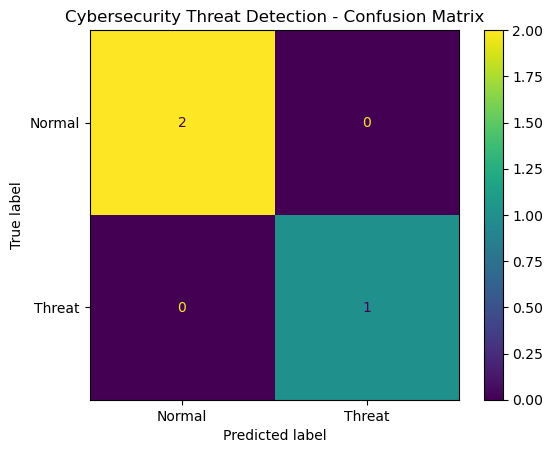

In [14]:
Confusion Matrix---> graph ---> display 

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Threat"]
)

disp.plot()
plt.title("Cybersecurity Threat Detection - Confusion Matrix")
plt.show()